In [1]:
%load_ext autoreload
%autoreload 2


# Solar Irradiation — BigQuery Quickstart (Kampala variables + irradiation)

This notebook shows how to:
- Connect to our BigQuery dataset
- (Optionally) create the long NASA variables table
- Create a table function to fetch nearest-grid **daily** variables
- Fetch **Kampala** nearest variables and join with **irradiation**
- Plot **daily** and **monthly** normalized series together

**Dataset:** `solar-irradiation-estimation.solar_warehouse` (EU)  
**Tables you will use:**
- `irradiance_daily` — daily GHI/DHI/DNI (kWh/m²/day), partitioned by `date`
- `nasa_daily_vars_long` — daily NASA variables in long format (one row per `(date, lat, lon, variable_id)`)



## Prerequisites

Authenticate once on your machine:
```bash
gcloud auth application-default login
gcloud config set project solar-irradiation-estimation
```


In [ ]:
# Optional: install needed libs (uncomment)
# %pip install --quiet google-cloud-bigquery pandas pyarrow matplotlib


In [2]:
from __future__ import annotations

from typing import Optional, Sequence, Iterable, List
from datetime import date
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt  # one chart per cell, no custom colors
from google.cloud import bigquery
from google.cloud.bigquery import ScalarQueryParameter
from matplotlib.typing import MarkerType

PROJECT_ID: str = "solar-irradiation-estimation"
DATASET: str = "solar_warehouse"
DATASET_FQN: str = f"{PROJECT_ID}.{DATASET}"
print(f"Using dataset: {DATASET_FQN}")

Using dataset: solar-irradiation-estimation.solar_warehouse


In [3]:
def create_client(project: Optional[str] = None) -> bigquery.Client:
    """Create an authenticated BigQuery client using ADC or a service account."""
    return bigquery.Client(project=project or None)


def query_to_dataframe(
    client: bigquery.Client,
    sql: str,
    parameters: Optional[Sequence[ScalarQueryParameter]] = None,
) -> pd.DataFrame:
    """Run a (parameterized) query and return results as a pandas DataFrame."""
    job_config: Optional[bigquery.QueryJobConfig] = None
    if parameters:
        job_config = bigquery.QueryJobConfig(query_parameters=list(parameters))
    job = client.query(sql, job_config=job_config)
    result = job.result()
    try:
        df: pd.DataFrame = result.to_dataframe(create_bqstorage_client=True)
    except Exception:
        df = result.to_dataframe(create_bqstorage_client=False)
    return df


def call_fn_nearest_point(
    client: bigquery.Client,
    dataset_fqn: str,
    *,
    lat: float,
    lon: float,
    start_date: date,
    end_date: date,
    max_km: Optional[float] = 100.0,
) -> pd.DataFrame:
    """Call the irradiance nearest-point function and return daily rows by source."""
    sql = f"""
    SELECT *
    FROM `{dataset_fqn}.fn_nearest_point`(@lat, @lon, @start_date, @end_date, @max_km)
    ORDER BY date, source
    """
    params = [
        ScalarQueryParameter("lat", "FLOAT64", lat),
        ScalarQueryParameter("lon", "FLOAT64", lon),
        ScalarQueryParameter("start_date", "DATE", start_date),
        ScalarQueryParameter("end_date", "DATE", end_date),
        ScalarQueryParameter("max_km", "FLOAT64", max_km),
    ]
    return query_to_dataframe(client, sql, params)

def fetch_nearest_vars_daily(
    client: bigquery.Client,
    dataset_fqn: str,
    *,
    lat: float,
    lon: float,
    start_date: date,
    end_date: date,
    variable_ids: Iterable[str],
    max_km: Optional[float] = 100.0,
) -> pd.DataFrame:
    """Fetch nearest-grid daily values for multiple variables and return a wide DataFrame."""
    dfs: List[pd.DataFrame] = []
    for var in variable_ids:
        sql = f"""
        SELECT date, value AS {var}
        FROM `{dataset_fqn}.fn_nearest_var_daily`(@var_id, @lat, @lon, @start_date, @end_date, @max_km)
        ORDER BY date
        """
        params = [
            ScalarQueryParameter("var_id", "STRING", var),
            ScalarQueryParameter("lat", "FLOAT64", lat),
            ScalarQueryParameter("lon", "FLOAT64", lon),
            ScalarQueryParameter("start_date", "DATE", start_date),
            ScalarQueryParameter("end_date", "DATE", end_date),
            ScalarQueryParameter("max_km", "FLOAT64", max_km),
        ]
        df_var = query_to_dataframe(client, sql, params)
        dfs.append(df_var)

    df_wide = dfs[0]
    for df_next in dfs[1:]:
        df_wide = pd.merge(df_wide, df_next, on="date", how="outer")
    df_wide = df_wide.sort_values("date").reset_index(drop=True)
    return df_wide


## Fetch Kampala nearest variables and join with irradiation


In [4]:
client = create_client(PROJECT_ID)
# Kampala
site_lat: float = 0.3476
site_lon: float = 32.5825
start_date: date = date(2024, 1, 1)
end_date:   date = date(2024, 12, 31)

# Variables to pull
vars_to_get: List[str] = ["temperature", "relative_humidity", "aod_550"]

# Variables (nearest daily)
df_vars_daily = fetch_nearest_vars_daily(
    client, DATASET_FQN,
    lat=site_lat, lon=site_lon,
    start_date=start_date, end_date=end_date,
    variable_ids=vars_to_get, max_km=100.0
)

# Irradiance (nearest daily, NASA only for overlay)
df_irr_daily = call_fn_nearest_point(
    client, DATASET_FQN,
    lat=site_lat, lon=site_lon,
    start_date=start_date, end_date=end_date,
    max_km=100.0
)
df_irr_nasa = df_irr_daily[df_irr_daily["source"] == "NASA"][["date", "ghi_kwh_m2_day"]].copy()

# Join
df_join_daily = pd.merge(df_irr_nasa, df_vars_daily, on="date", how="inner").sort_values("date")
df_join_daily.head()

/home/jan/.pyenv/versions/.venv_irradiation/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/.pyenv/versions/.venv_irradiation/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,date,ghi_kwh_m2_day,temperature,relative_humidity,aod_550
0,2024-01-01,4.00,21.17,85.40,0.38
1,2024-01-02,4.52,21.32,85.46,0.29
2,2024-01-03,4.09,21.24,82.15,0.36
3,2024-01-04,5.80,21.66,78.62,0.41
4,2024-01-05,3.68,22.82,73.85,0.39



### Plot: Daily normalized (GHI + variables)


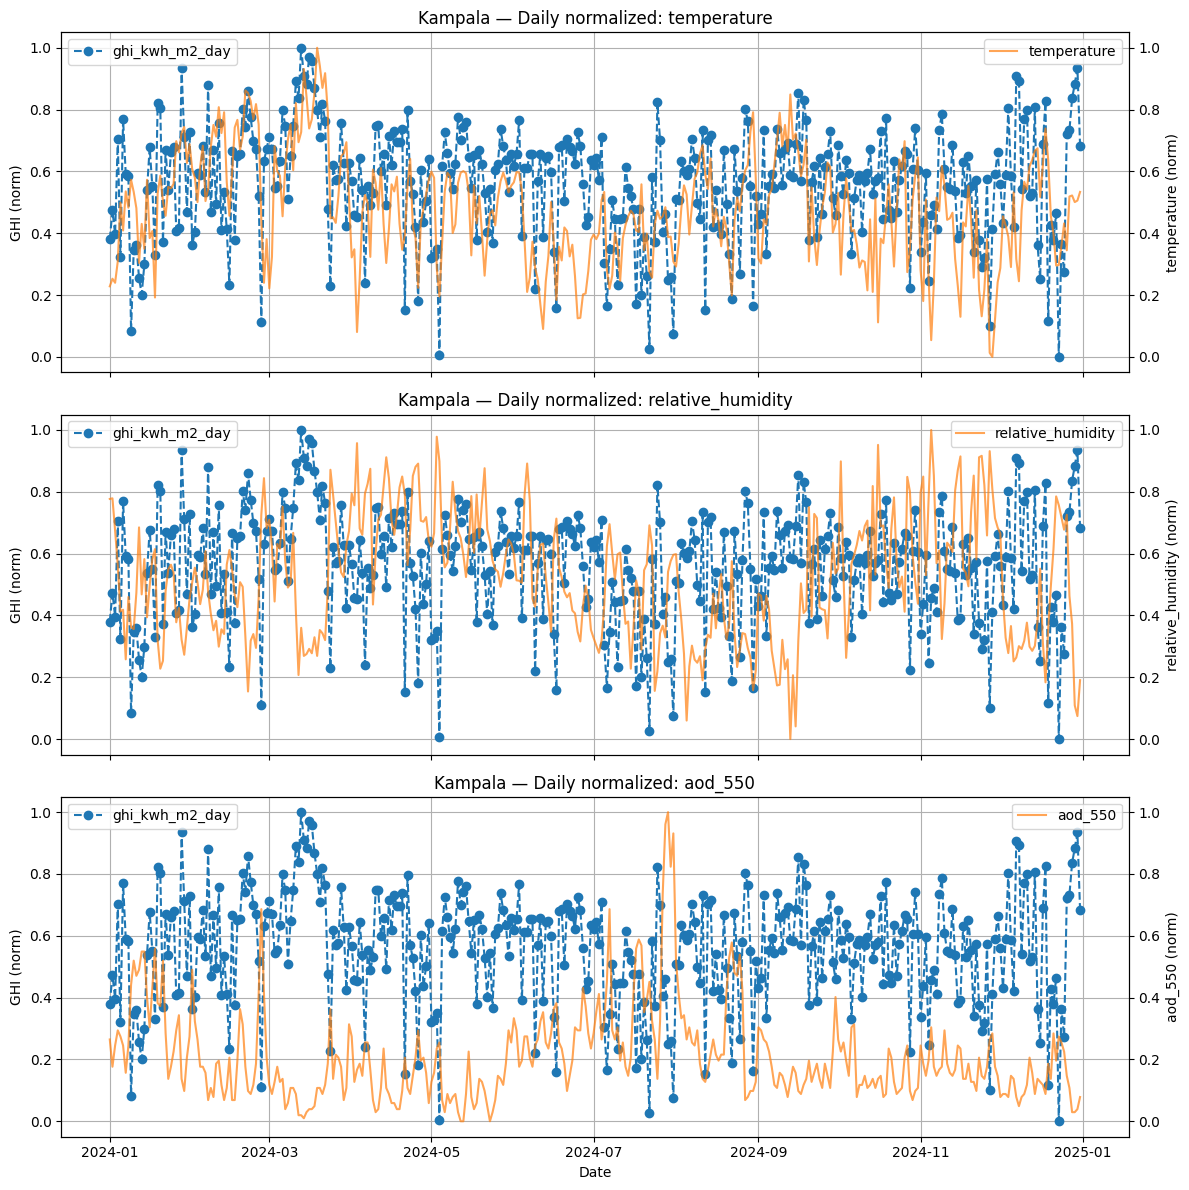

In [13]:
from __future__ import annotations
from typing import Sequence
import matplotlib.pyplot as plt
import pandas as pd

def min_max_normalize(series: pd.Series) -> pd.Series:
    smin, smax = series.min(), series.max()
    if pd.isna(smin) or pd.isna(smax) or smax == smin:
        return series * 0.0
    return (series - smin) / (smax - smin)

def plot_ghi_overlays(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    ghi_col: str = "ghi_kwh_m2_day",
    var_cols: Sequence[str] = ("temperature", "relative_humidity", "aod_550"),
    title_prefix: str = "Kampala — Daily normalized",
    normalize: bool = True,
) -> None:
    """
    Makes one figure with stacked panels (one per variable), overlaying GHI with that variable.
    Accepts either:
      - a real column named `date_col`, or
      - `date_col` being the DataFrame index name.
    """
    # Build df2 with a Date/Month index either way
    if date_col in df.columns:
        df2 = df[[date_col, ghi_col, *var_cols]].copy().sort_values(date_col).set_index(date_col)
    else:
        # Use the existing index, but ensure it’s sorted
        df2 = df[[ghi_col, *var_cols]].copy().sort_index()

    fig, axs = plt.subplots(len(var_cols), 1, figsize=(12, 4 * len(var_cols)), sharex=True)

    for i, var in enumerate(var_cols):
        plot_df = df2[[ghi_col, var]].copy()
        if normalize:
            plot_df[ghi_col] = min_max_normalize(plot_df[ghi_col])
            plot_df[var]     = min_max_normalize(plot_df[var])

        ax = axs.flatten()[i]
        # Left axis: GHI
        ax.plot(plot_df.index, plot_df[ghi_col], label=ghi_col, marker='o', linestyle='--')
        # Right axis: variable
        ax2 = ax.twinx()
        ax2.plot(plot_df.index, plot_df[var], color="tab:orange", label=var, alpha=0.7)

        ax.set_title(f"{title_prefix}: {var}")
        ax.set_ylabel("GHI (norm)" if normalize else "GHI")
        ax.grid(True)
        ax.legend(loc="upper left")
        ax2.set_ylabel(f"{var} (norm)" if normalize else var)
        ax2.legend(loc="upper right")

    axs[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

# Use your selected variables; this will produce three separate figures
plot_ghi_overlays(
    df_join_daily,
    var_cols=vars_to_get,  # e.g., ["temperature", "relative_humidity", "aod_550"]
)



### Plot: Monthly normalized means (GHI + variables)


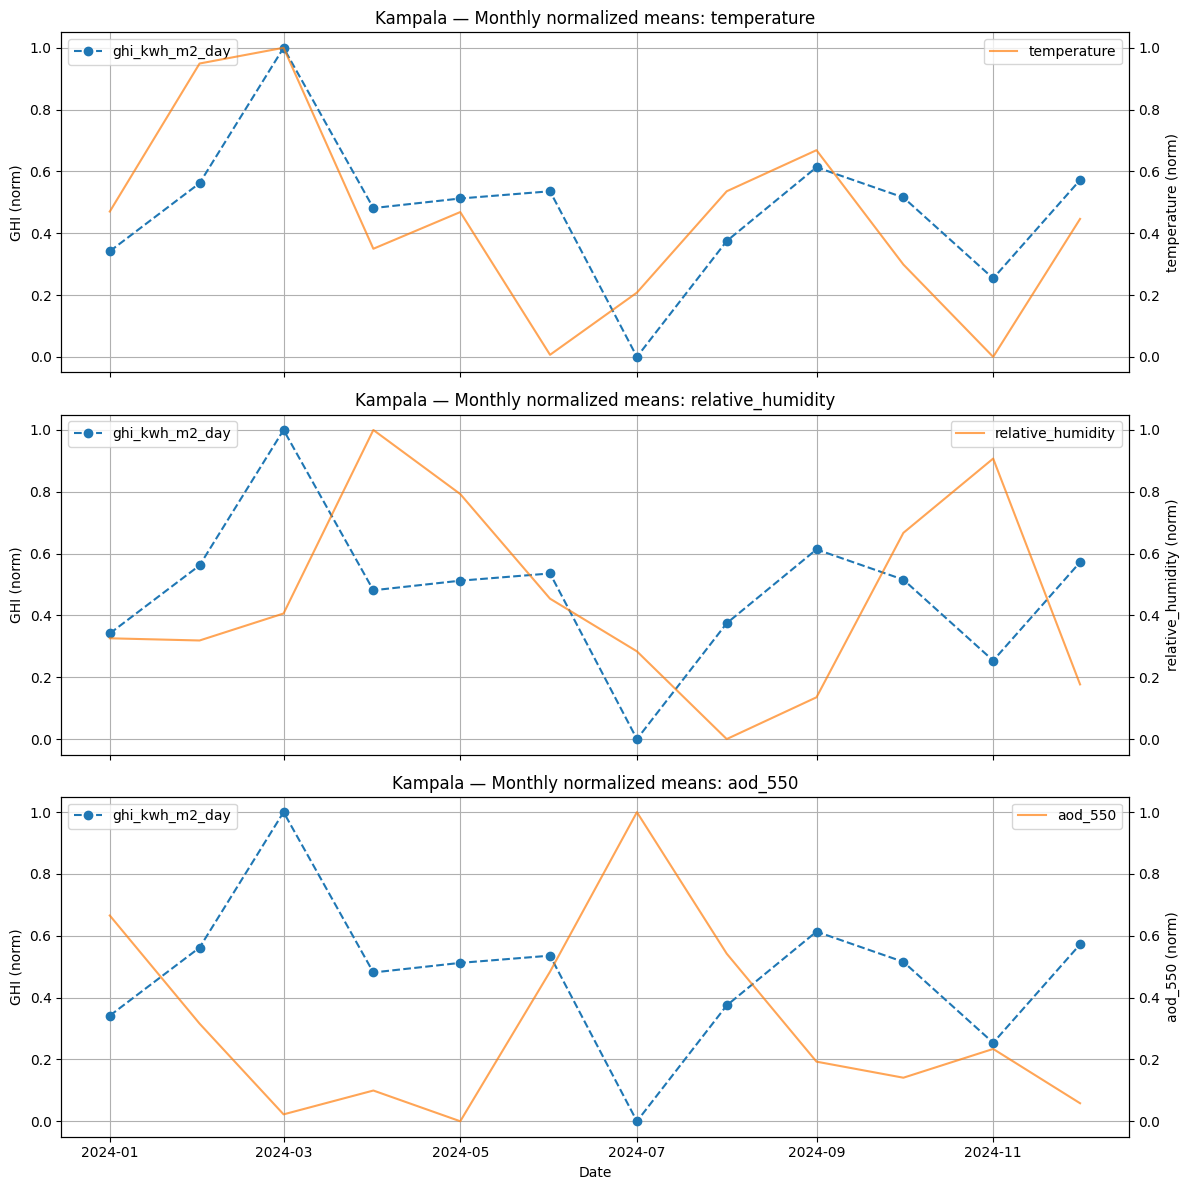

In [14]:
df_join_daily['month'] = pd.to_datetime(df_join_daily['date']).dt.to_period('M').dt.to_timestamp()
monthly = (
    df_join_daily.groupby('month', as_index=False)[['ghi_kwh_m2_day'] + vars_to_get]
    .mean()
    .sort_values('month')
)

df_month_plot = monthly.set_index('month')
plot_ghi_overlays(
    df_month_plot,
    date_col='month',  # still tell it the logical time field name
    var_cols=vars_to_get,
    title_prefix='Kampala — Monthly normalized means',
)